In [1]:
# ============================================================
# RQ7: De-confounded Source Classification
# Journal-paper extension of the thesis RQ5
# ============================================================
# This notebook tests whether the AI-vs-human classification finding
# survives once we remove the lines-of-code (LOC) confound.
#
# Three configurations are compared:
#   A. All 5 features (replicates thesis baseline)
#   B. All features EXCEPT LOC
#   C. All features normalized per-LOC
#
# Expected runtime: under 1 minute. No GPU required.
# ============================================================


# ============================================================
# Cell 1 — Imports
# ============================================================
import ast
import re
import textwrap
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              classification_report, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
print("Setup complete.")


# ============================================================
# Cell 2 — Load dataset
# ============================================================
# Update this path to match your Kaggle dataset slug.
# To find it: in your Kaggle notebook, look at the "Input" panel
# on the right; click the CSV; the path appears at the top.

DATA_PATH = "/kaggle/input/datasets/bartuaslan/ai-solutions-dataset/humaneval_ai_solutions_dataset.csv"

df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df)} rows.")
print(f"Columns: {list(df.columns)}")


# ============================================================
# Cell 3 — Feature extraction
# ============================================================
# We compute 5 features per code snippet: LOC, returns, ifs, loops, comments.
#
# For AST counts (returns/ifs/loops) we parse the code. StarCoder2-3B
# output sometimes has indentation quirks, so we apply a small cleanup
# before parsing. LOC and comments use simple line-based counts on the
# raw text — matching the thesis methodology.
#
# Counts are taken over the ENTIRE generated output (not just the target
# function), to match the LOC convention used in the thesis.

def fix_indentation(code):
    """Re-indent any zero-indent body lines (StarCoder2-3B output quirk)."""
    lines = str(code).split('\n')
    fixed = []
    for line in lines:
        if line and not line[0].isspace() and line.strip():
            # If a top-level def/class/import, leave it alone
            if re.match(r'^(def |class |import |from |@|if __name__)', line):
                fixed.append(line)
            else:
                fixed.append('    ' + line)
        else:
            fixed.append(line)
    return '\n'.join(fixed)


def count_ast_nodes(code, prompt):
    """
    Count returns/ifs/loops in the code. Try several parsing strategies
    so we maximize how many snippets we can extract features from.
    Returns dict with counts and parse_ok flag.
    """
    code = str(code)
    candidates = [
        # Strategy 1: prompt + fixed body (most realistic for HumanEval format)
        str(prompt) + fix_indentation(code),
        # Strategy 2: just the code as-is
        code,
        # Strategy 3: dedented then wrapped in dummy function
        "def _d():\n" + "\n".join("    " + l for l in textwrap.dedent(code).split('\n')),
    ]
    tree = None
    for candidate in candidates:
        try:
            tree = ast.parse(candidate)
            break
        except (SyntaxError, IndentationError):
            continue

    if tree is None:
        return {"returns": 0, "ifs": 0, "loops": 0, "parse_ok": False}

    r = i = l = 0
    for n in ast.walk(tree):
        if isinstance(n, ast.Return):       r += 1
        elif isinstance(n, ast.If):         i += 1
        elif isinstance(n, (ast.For, ast.While)): l += 1
    return {"returns": r, "ifs": i, "loops": l, "parse_ok": True}


def count_loc(code):
    """Non-blank, non-comment-only lines (matches thesis LOC convention)."""
    return sum(
        1 for line in str(code).split('\n')
        if line.strip() and not line.strip().startswith('#')
    )


def count_comments(code):
    """Lines starting with #."""
    return sum(1 for line in str(code).split('\n') if line.strip().startswith('#'))


# Build the 328-row feature table
rows = []
for _, r in df.iterrows():
    for code_col, label in [('human_solution', 'human'), ('ai_solution', 'ai')]:
        code = r[code_col]
        feats = count_ast_nodes(code, r['prompt'])
        feats['loc'] = count_loc(code)
        feats['comments'] = count_comments(code)
        feats['source'] = label
        feats['task_id'] = r['task_id']
        rows.append(feats)

features = pd.DataFrame(rows)
print(f"Feature table: {features.shape}")
print(f"Parse failures: {(~features['parse_ok']).sum()} / {len(features)}")
print(f"  Human: {((~features['parse_ok']) & (features['source']=='human')).sum()}")
print(f"  AI:    {((~features['parse_ok']) & (features['source']=='ai')).sum()}")


# ============================================================
# Cell 4 — Sanity check against thesis
# ============================================================
print("\nMean features by source:")
print(features.groupby('source')[['loc','returns','ifs','loops','comments']].mean().round(2))
print("\nThesis reported: Human LOC=6.3, AI LOC=31.8 (ratio 5x)")


# ============================================================
# Cell 5 — Build feature matrices for three configurations
# ============================================================
y = (features['source'] == 'ai').astype(int).values  # 1 = AI, 0 = human

# Config A: original five features
X_A = features[['loc', 'returns', 'ifs', 'loops', 'comments']].values
feat_A = ['loc', 'returns', 'ifs', 'loops', 'comments']

# Config B: drop LOC
X_B = features[['returns', 'ifs', 'loops', 'comments']].values
feat_B = ['returns', 'ifs', 'loops', 'comments']

# Config C: per-LOC normalization
loc_safe = features['loc'].values + 1  # +1 to avoid division by zero
X_C = np.column_stack([
    features['returns'].values  / loc_safe,
    features['ifs'].values      / loc_safe,
    features['loops'].values    / loc_safe,
    features['comments'].values / loc_safe,
])
feat_C = ['returns/loc', 'ifs/loc', 'loops/loc', 'comments/loc']

configs = [
    ("A: all 5 features (thesis baseline)", X_A, feat_A),
    ("B: without LOC",                      X_B, feat_B),
    ("C: per-LOC normalized",               X_C, feat_C),
]
print("Three configurations prepared.")


# ============================================================
# Cell 6 — Train and evaluate
# ============================================================
def evaluate(X, y, feature_names, seed=SEED):
    """Train Random Forest, return CV F1 + held-out metrics + importances."""
    rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=seed)

    # 5-fold stratified cross-validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    cv_f1_scores = cross_val_score(rf, X, y, cv=skf, scoring='f1')

    # 80/20 train-test split (matches thesis)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )
    rf.fit(X_tr, y_tr)
    y_pred  = rf.predict(X_te)
    y_proba = rf.predict_proba(X_te)[:, 1]

    return {
        'cv_f1_mean': cv_f1_scores.mean(),
        'cv_f1_std':  cv_f1_scores.std(),
        'accuracy':   accuracy_score(y_te, y_pred),
        'f1':         f1_score(y_te, y_pred),
        'auc':        roc_auc_score(y_te, y_proba),
        'importance': dict(zip(feature_names, rf.feature_importances_)),
        'y_test': y_te, 'y_pred': y_pred,
    }


results = {}
for name, X, feats in configs:
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    res = evaluate(X, y, feats)
    results[name] = res
    print(f"  5-fold CV F1:  {res['cv_f1_mean']:.3f} (+/- {res['cv_f1_std']:.3f})")
    print(f"  Test accuracy: {res['accuracy']:.3f}")
    print(f"  Test F1:       {res['f1']:.3f}")
    print(f"  Test AUC-ROC:  {res['auc']:.3f}")
    print(f"  Feature importances (sorted):")
    for f, imp in sorted(res['importance'].items(), key=lambda x: -x[1]):
        print(f"    {f:20s} {imp:.3f}")


# ============================================================
# Cell 7 — Summary comparison table
# ============================================================
summary = pd.DataFrame({
    name: {
        'CV F1':        f"{r['cv_f1_mean']:.3f}",
        'Test acc.':    f"{r['accuracy']:.3f}",
        'Test F1':      f"{r['f1']:.3f}",
        'Test AUC':     f"{r['auc']:.3f}",
    }
    for name, r in results.items()
}).T

print("\n" + "="*60)
print("SUMMARY — RQ7 De-confounded Classification")
print("="*60)
print(summary)
print()
print("Interpretation guide:")
print("- Config A reproduces the thesis baseline (~95% acc expected).")
print("- Config B tests whether stylistic signal survives without LOC.")
print("  If accuracy stays high: AI/human differ in MORE than just length.")
print("  If accuracy drops near 50%: separation was almost entirely length.")
print("- Config C is the strictest control: features as ratios of code length.")


# ============================================================
# Cell 8 — Save outputs for the paper
# ============================================================
features.to_csv('rq7_features.csv', index=False)
summary.to_csv('rq7_summary.csv')
print("\nSaved: rq7_features.csv (full feature matrix)")
print("Saved: rq7_summary.csv (config comparison table)")

Setup complete.
Loaded 164 rows.
Columns: ['task_id', 'prompt', 'human_solution', 'ai_solution', 'test', 'entry_point']
Feature table: (328, 8)
Parse failures: 153 / 328
  Human: 0
  AI:    153

Mean features by source:
          loc  returns   ifs  loops  comments
source                                       
ai      31.77     0.38  0.17   0.12      0.92
human    6.29     1.63  1.20   0.72      0.01

Thesis reported: Human LOC=6.3, AI LOC=31.8 (ratio 5x)
Three configurations prepared.

A: all 5 features (thesis baseline)
  5-fold CV F1:  0.997 (+/- 0.006)
  Test accuracy: 1.000
  Test F1:       1.000
  Test AUC-ROC:  1.000
  Feature importances (sorted):
    returns              0.447
    loc                  0.400
    ifs                  0.086
    loops                0.048
    comments             0.020

B: without LOC
  5-fold CV F1:  0.976 (+/- 0.028)
  Test accuracy: 0.970
  Test F1:       0.971
  Test AUC-ROC:  1.000
  Feature importances (sorted):
    returns              0.77

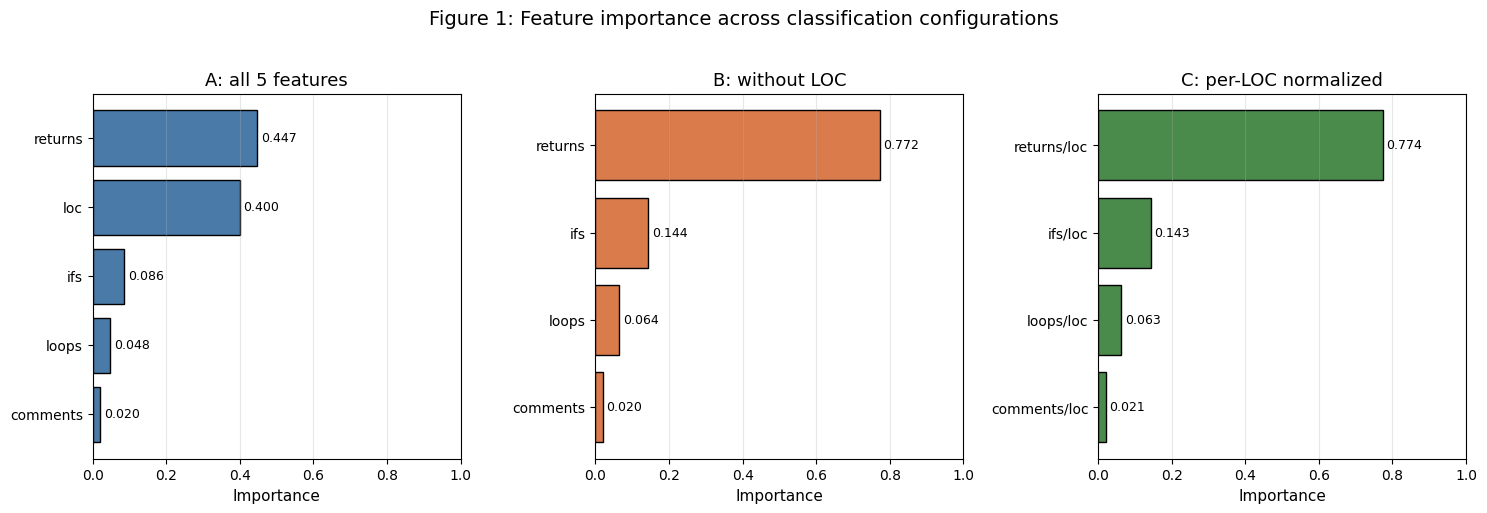

Saved Figure 1.


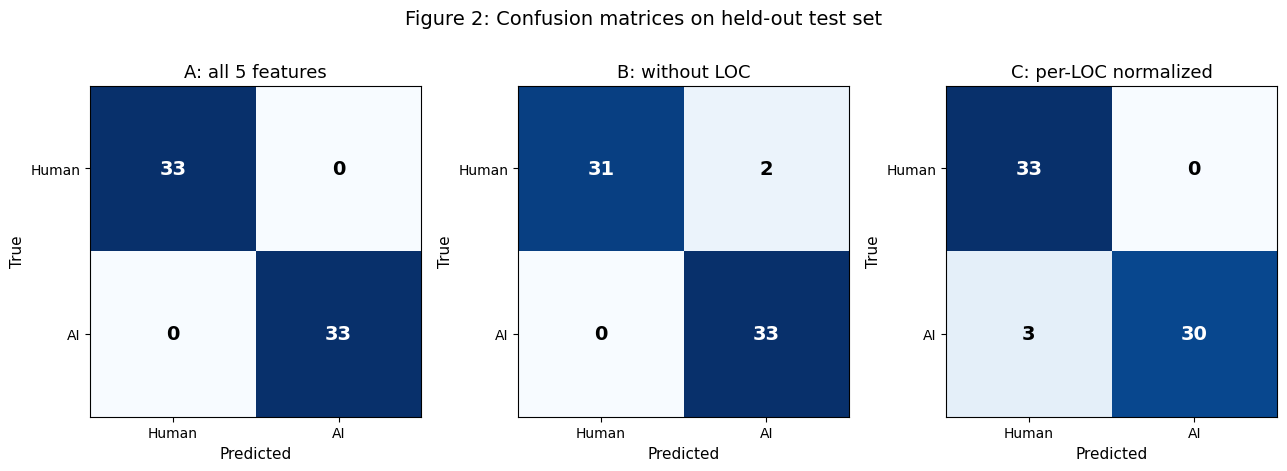

Saved Figure 2.


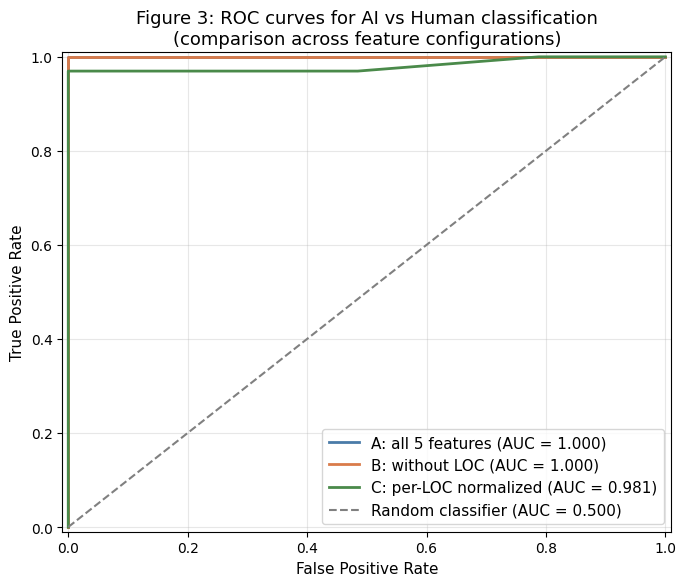

Saved Figure 3.


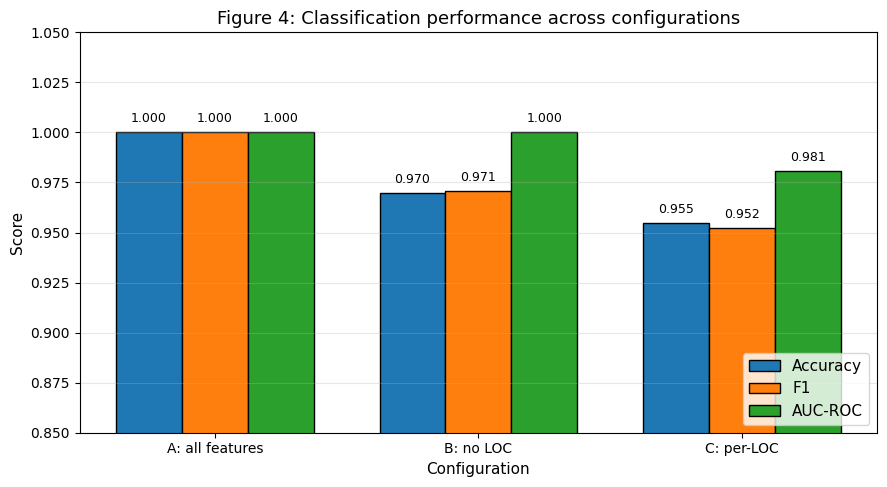

Saved Figure 4.

All RQ7 figures saved as PDF (paper) and PNG (preview):
  rq7_fig1_feature_importance.{pdf,png}
  rq7_fig2_confusion_matrices.{pdf,png}
  rq7_fig3_roc_curves.{pdf,png}
  rq7_fig4_metrics_comparison.{pdf,png}


In [3]:
import ast, re, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc

# ============================================================
# Load and rebuild the feature matrix
# (re-runs the same extraction as the original RQ7 notebook)
# ============================================================
DATA_PATH = "/kaggle/input/datasets/bartuaslan/ai-solutions-dataset/humaneval_ai_solutions_dataset.csv"
df = pd.read_csv(DATA_PATH)

def fix_indentation(code):
    lines = str(code).split('\n')
    fixed = []
    for line in lines:
        if line and not line[0].isspace() and line.strip():
            if re.match(r'^(def |class |import |from |@|if __name__)', line):
                fixed.append(line)
            else:
                fixed.append('    ' + line)
        else:
            fixed.append(line)
    return '\n'.join(fixed)

def count_ast_nodes(code, prompt):
    code = str(code)
    candidates = [
        str(prompt) + fix_indentation(code),
        code,
        "def _d():\n" + "\n".join("    " + l for l in textwrap.dedent(code).split('\n')),
    ]
    tree = None
    for c in candidates:
        try:
            tree = ast.parse(c); break
        except (SyntaxError, IndentationError):
            continue
    if tree is None:
        return {"returns": 0, "ifs": 0, "loops": 0, "parse_ok": False}
    r = i = l = 0
    for n in ast.walk(tree):
        if isinstance(n, ast.Return): r += 1
        elif isinstance(n, ast.If): i += 1
        elif isinstance(n, (ast.For, ast.While)): l += 1
    return {"returns": r, "ifs": i, "loops": l, "parse_ok": True}

def count_loc(code):
    return sum(1 for line in str(code).split('\n')
               if line.strip() and not line.strip().startswith('#'))

def count_comments(code):
    return sum(1 for line in str(code).split('\n') if line.strip().startswith('#'))

rows = []
for _, r in df.iterrows():
    for col, label in [('human_solution', 'human'), ('ai_solution', 'ai')]:
        code = r[col]
        feats = count_ast_nodes(code, r['prompt'])
        feats['loc'] = count_loc(code)
        feats['comments'] = count_comments(code)
        feats['source'] = label
        rows.append(feats)
features = pd.DataFrame(rows)

SEED = 42
y = (features['source'] == 'ai').astype(int).values
loc_safe = features['loc'].values + 1

configs = {
    'A: all 5 features': (
        features[['loc','returns','ifs','loops','comments']].values,
        ['loc','returns','ifs','loops','comments']
    ),
    'B: without LOC': (
        features[['returns','ifs','loops','comments']].values,
        ['returns','ifs','loops','comments']
    ),
    'C: per-LOC normalized': (
        np.column_stack([
            features['returns'].values / loc_safe,
            features['ifs'].values / loc_safe,
            features['loops'].values / loc_safe,
            features['comments'].values / loc_safe,
        ]),
        ['returns/loc','ifs/loc','loops/loc','comments/loc']
    ),
}

# Train each config, store everything we need for figures
results = {}
for name, (X, feats) in configs.items():
    rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=SEED)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )
    rf.fit(X_tr, y_tr)
    y_pred = rf.predict(X_te)
    y_proba = rf.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, y_proba)
    results[name] = {
        'features': feats,
        'importances': rf.feature_importances_,
        'y_test': y_te,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'fpr': fpr, 'tpr': tpr,
        'auc': auc(fpr, tpr),
    }

# Publication style
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})


# ============================================================
# Figure 1 — Feature importance comparison across configs
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#4a7ba8', '#d97b4a', '#4a8a4a']

for i, (name, r) in enumerate(results.items()):
    # Sort by importance
    order = np.argsort(r['importances'])[::-1]
    sorted_feats = [r['features'][j] for j in order]
    sorted_imps = r['importances'][order]

    axes[i].barh(range(len(sorted_feats)), sorted_imps,
                 color=colors[i], edgecolor='black')
    axes[i].set_yticks(range(len(sorted_feats)))
    axes[i].set_yticklabels(sorted_feats, fontsize=10)
    axes[i].invert_yaxis()
    axes[i].set_xlabel('Importance')
    axes[i].set_title(name)
    axes[i].grid(axis='x', alpha=0.3)
    axes[i].set_xlim(0, 1.0)

    for j, imp in enumerate(sorted_imps):
        axes[i].text(imp + 0.01, j, f'{imp:.3f}',
                     va='center', fontsize=9)

plt.suptitle('Figure 1: Feature importance across classification configurations',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('rq7_fig1_feature_importance.pdf')
plt.savefig('rq7_fig1_feature_importance.png')
plt.show()
print("Saved Figure 1.")


# ============================================================
# Figure 2 — Confusion matrices side by side
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

for i, (name, r) in enumerate(results.items()):
    cm = confusion_matrix(r['y_test'], r['y_pred'])
    im = axes[i].imshow(cm, cmap='Blues', aspect='equal')

    # Annotate cells with counts
    for row in range(cm.shape[0]):
        for col in range(cm.shape[1]):
            value = cm[row, col]
            text_color = 'white' if value > cm.max()/2 else 'black'
            axes[i].text(col, row, str(value),
                         ha='center', va='center', fontsize=14,
                         color=text_color, fontweight='bold')

    axes[i].set_xticks([0, 1])
    axes[i].set_yticks([0, 1])
    axes[i].set_xticklabels(['Human', 'AI'])
    axes[i].set_yticklabels(['Human', 'AI'])
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')
    axes[i].set_title(name)

plt.suptitle('Figure 2: Confusion matrices on held-out test set',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('rq7_fig2_confusion_matrices.pdf')
plt.savefig('rq7_fig2_confusion_matrices.png')
plt.show()
print("Saved Figure 2.")


# ============================================================
# Figure 3 — ROC curves overlaid
# ============================================================
fig, ax = plt.subplots(figsize=(7, 6))

for i, (name, r) in enumerate(results.items()):
    ax.plot(r['fpr'], r['tpr'], color=colors[i], linewidth=2,
            label=f"{name} (AUC = {r['auc']:.3f})")

ax.plot([0, 1], [0, 1], linestyle='--', color='gray',
        label='Random classifier (AUC = 0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Figure 3: ROC curves for AI vs Human classification\n(comparison across feature configurations)')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)
plt.tight_layout()
plt.savefig('rq7_fig3_roc_curves.pdf')
plt.savefig('rq7_fig3_roc_curves.png')
plt.show()
print("Saved Figure 3.")


# ============================================================
# Figure 4 — Performance metrics comparison (bar chart)
# ============================================================
from sklearn.metrics import accuracy_score, f1_score

metrics_data = {
    'Accuracy':  [accuracy_score(r['y_test'], r['y_pred']) for r in results.values()],
    'F1':        [f1_score(r['y_test'], r['y_pred'])       for r in results.values()],
    'AUC-ROC':   [r['auc']                                  for r in results.values()],
}

config_names = list(results.keys())
short_names = ['A: all features', 'B: no LOC', 'C: per-LOC']

x = np.arange(len(config_names))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
for i, (metric, values) in enumerate(metrics_data.items()):
    bars = ax.bar(x + i*width - width, values, width,
                  label=metric, edgecolor='black')
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', fontsize=9)

ax.set_xlabel('Configuration')
ax.set_ylabel('Score')
ax.set_title('Figure 4: Classification performance across configurations')
ax.set_xticks(x)
ax.set_xticklabels(short_names)
ax.set_ylim(0.85, 1.05)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('rq7_fig4_metrics_comparison.pdf')
plt.savefig('rq7_fig4_metrics_comparison.png')
plt.show()
print("Saved Figure 4.")

print("\nAll RQ7 figures saved as PDF (paper) and PNG (preview):")
print("  rq7_fig1_feature_importance.{pdf,png}")
print("  rq7_fig2_confusion_matrices.{pdf,png}")
print("  rq7_fig3_roc_curves.{pdf,png}")
print("  rq7_fig4_metrics_comparison.{pdf,png}")

In [ ]:
# ============================================================
# RQ7: De-confounded Source Classification
# ============================================================

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

In [ ]:
# ============================================================
# Load and extract features (EXACTLY matching RQ5)
# ============================================================
DATA_PATH = "/kaggle/input/datasets/bartuaslan/ai-solutions-dataset/humaneval_ai_solutions_dataset.csv"
df = pd.read_csv(DATA_PATH)

def extract_features(code):
    """Matches RQ5 notebook feature extraction exactly."""
    code_str = str(code) if pd.notna(code) else ""
    return {
        'loc':      len([l for l in code_str.split('\n') if l.strip()]),
        'returns':  code_str.count('return'),
        'ifs':      code_str.count('if '),
        'loops':    code_str.count('for ') + code_str.count('while '),
        'comments': len([l for l in code_str.split('\n') if l.strip().startswith('#')]),
    }

rows = []
for _, r in df.iterrows():
    h = extract_features(r['human_solution']); h['source'] = 0; rows.append(h)
    a = extract_features(r['ai_solution']);    a['source'] = 1; rows.append(a)

features_df = pd.DataFrame(rows)
y = features_df['source'].values

print(f"Dataset: {len(features_df)} samples ({sum(y==0)} human, {sum(y==1)} AI)")
print("\nMean features by source:")
print(features_df.groupby('source')[['loc','returns','ifs','loops','comments']].mean().round(2))
print("\nRQ5 reference: Human LOC=6.3, AI LOC=31.8")

# ============================================================
# Three configurations
# ============================================================
X_A = features_df[['loc', 'returns', 'ifs', 'loops', 'comments']].values
feat_A = ['loc', 'returns', 'ifs', 'loops', 'comments']

X_B = features_df[['returns', 'ifs', 'loops', 'comments']].values
feat_B = ['returns', 'ifs', 'loops', 'comments']

loc_safe = features_df['loc'].values + 1
X_C = np.column_stack([
    features_df['returns'].values  / loc_safe,
    features_df['ifs'].values      / loc_safe,
    features_df['loops'].values    / loc_safe,
    features_df['comments'].values / loc_safe,
])
feat_C = ['returns/loc', 'ifs/loc', 'loops/loc', 'comments/loc']

configs = [
    ("A: all 5 features (matches RQ5)", X_A, feat_A),
    ("B: without LOC",                   X_B, feat_B),
    ("C: per-LOC normalized",            X_C, feat_C),
]

# ============================================================
# Evaluation function (matches RQ5 setup exactly)
# ============================================================
def evaluate(X, y, feature_names, seed=SEED):
    rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=seed)
    
    # Train-test split (matches RQ5)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )
    
    # Scale features (matches RQ5)
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)
    
    # 5-fold CV on training set (matches RQ5)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    cv_f1_scores = cross_val_score(rf, X_tr_s, y_tr, cv=skf, scoring='f1')
    
    # Final fit and evaluation
    rf.fit(X_tr_s, y_tr)
    y_pred  = rf.predict(X_te_s)
    y_proba = rf.predict_proba(X_te_s)[:, 1]
    
    return {
        'cv_f1_mean': cv_f1_scores.mean(),
        'cv_f1_std':  cv_f1_scores.std(),
        'accuracy':   accuracy_score(y_te, y_pred),
        'f1':         f1_score(y_te, y_pred),
        'auc':        roc_auc_score(y_te, y_proba),
        'importance': dict(zip(feature_names, rf.feature_importances_)),
    }

# ============================================================
# Run all three configurations
# ============================================================
results = {}
for name, X, feats in configs:
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    res = evaluate(X, y, feats)
    results[name] = res
    print(f"  5-fold CV F1 (on train):  {res['cv_f1_mean']:.4f} (+/- {res['cv_f1_std']:.4f})")
    print(f"  Test accuracy:            {res['accuracy']:.4f}")
    print(f"  Test F1:                  {res['f1']:.4f}")
    print(f"  Test AUC-ROC:             {res['auc']:.4f}")
    print(f"  Feature importances:")
    for f, imp in sorted(res['importance'].items(), key=lambda x: -x[1]):
        print(f"    {f:20s} {imp:.4f}")

# ============================================================
# Sanity check: Config A MUST match RQ5
# ============================================================
print("\n" + "="*60)
print("SANITY CHECK — Config A should match RQ5 exactly")
print("="*60)
print(f"  RQ5 expected: Test acc=0.9545, CV F1=0.9621, LOC=0.649, Returns=0.205")
print(f"  Config A got: Test acc={results[configs[0][0]]['accuracy']:.4f}, "
      f"CV F1={results[configs[0][0]]['cv_f1_mean']:.4f}, "
      f"LOC={results[configs[0][0]]['importance']['loc']:.3f}, "
      f"Returns={results[configs[0][0]]['importance']['returns']:.3f}")

Dataset: 328 samples (164 human, 164 AI)

Mean features by source:
         loc  returns   ifs  loops  comments
source                                      
0        6.3     1.60  1.37   1.04      0.01
1       32.7     5.38  3.67   1.87      0.92

RQ5 reference: Human LOC=6.3, AI LOC=31.8

A: all 5 features (matches RQ5)
  5-fold CV F1 (on train):  0.9577 (+/- 0.0146)
  Test accuracy:            0.9545
  Test F1:                  0.9552
  Test AUC-ROC:             0.9982
  Feature importances:
    loc                  0.6488
    returns              0.2052
    ifs                  0.0603
    comments             0.0540
    loops                0.0317

B: without LOC
  5-fold CV F1 (on train):  0.8506 (+/- 0.0590)
  Test accuracy:            0.9242
  Test F1:                  0.9254
  Test AUC-ROC:             0.9715
  Feature importances:
    returns              0.5897
    ifs                  0.1584
    loops                0.1447
    comments             0.1073

C: per-LOC normalize

In [2]:
# ============================================================
# RQ7: Generate all paper outputs (5 files)
#   - rq7_features.csv
#   - rq7_fig1_feature_importance.pdf
#   - rq7_fig2_confusion_matrices.pdf
#   - rq7_fig3_roc_curves.pdf
#   - rq7_fig4_metrics_comparison.pdf
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              confusion_matrix, roc_curve, auc)

# ============================================================
# 1) Save rq7_features.csv (the full feature matrix)
# ============================================================
# Build full feature dataframe with source labels for export
features_export = features_df.copy()
features_export['source_label'] = features_export['source'].map({0: 'human', 1: 'ai'})

# Reorder columns for readability
features_export = features_export[['source_label', 'loc', 'returns', 'ifs', 'loops', 'comments']]
features_export.to_csv('rq7_features.csv', index=False)
print(f"Saved: rq7_features.csv ({len(features_export)} rows)")


# ============================================================
# 2) Re-run all three configs and capture full prediction data
# ============================================================
def evaluate_full(X, y, feature_names, seed=42):
    rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=seed)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)
    
    # CV F1 on training set
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    cv_f1 = cross_val_score(rf, X_tr_s, y_tr, cv=skf, scoring='f1')
    
    rf.fit(X_tr_s, y_tr)
    y_pred  = rf.predict(X_te_s)
    y_proba = rf.predict_proba(X_te_s)[:, 1]
    
    return {
        'feature_names': feature_names,
        'importances': rf.feature_importances_,
        'y_test':  y_te,
        'y_pred':  y_pred,
        'y_proba': y_proba,
        'accuracy':  accuracy_score(y_te, y_pred),
        'f1':        f1_score(y_te, y_pred),
        'auc':       roc_auc_score(y_te, y_proba),
        'cv_f1_mean': cv_f1.mean(),
        'cv_f1_std':  cv_f1.std(),
    }

plot_data = {
    'A': evaluate_full(X_A, y, feat_A),
    'B': evaluate_full(X_B, y, feat_B),
    'C': evaluate_full(X_C, y, feat_C),
}

# Color palette (consistent across all RQ7 figures)
BLUE   = "#2E5C8A"
ORANGE = "#C25E1F"
GREY   = "#555555"
GREEN  = "#3E7B3E"

config_titles = {
    'A': 'Config A: all 5 features',
    'B': 'Config B: without LOC',
    'C': 'Config C: per-LOC normalized',
}


# ============================================================
# 3) Figure 1: Feature Importance (three panels)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=300)

for ax, (cfg_key, data) in zip(axes, plot_data.items()):
    order = np.argsort(data['importances'])[::-1]
    names = [data['feature_names'][i] for i in order]
    imps  = [data['importances'][i] for i in order]
    
    # Highlight dominant feature in orange, others in blue
    colors = [ORANGE if i == 0 else BLUE for i in range(len(names))]
    
    ax.barh(range(len(names)), imps, color=colors, edgecolor='black', linewidth=0.6)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Feature importance', fontsize=10)
    ax.set_title(config_titles[cfg_key], fontsize=11)
    ax.set_xlim(0, max(imps) * 1.30)
    ax.grid(True, axis='x', alpha=0.3)
    
    for i, imp in enumerate(imps):
        ax.text(imp + 0.01, i, f'{imp:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('rq7_fig1_feature_importance.pdf', bbox_inches='tight', dpi=300)
plt.savefig('rq7_fig1_feature_importance.png', bbox_inches='tight', dpi=300)
plt.close()
print("Saved: rq7_fig1_feature_importance.pdf")


# ============================================================
# 4) Figure 2: Confusion Matrices (three panels)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=300)

for ax, (cfg_key, data) in zip(axes, plot_data.items()):
    cm = confusion_matrix(data['y_test'], data['y_pred'])
    
    im = ax.imshow(cm, cmap='Blues', interpolation='nearest', vmin=0, vmax=cm.max())
    
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Human', 'AI'], fontsize=10)
    ax.set_yticklabels(['Human', 'AI'], fontsize=10)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)
    ax.set_title(f"{config_titles[cfg_key]}\nAccuracy: {data['accuracy']:.3f}",
                 fontsize=11)
    
    for i in range(2):
        for j in range(2):
            value = cm[i, j]
            text_color = "white" if value > cm.max() / 2 else "black"
            ax.text(j, i, str(value), ha='center', va='center',
                    fontsize=16, fontweight='bold', color=text_color)

plt.tight_layout()
plt.savefig('rq7_fig2_confusion_matrices.pdf', bbox_inches='tight', dpi=300)
plt.savefig('rq7_fig2_confusion_matrices.png', bbox_inches='tight', dpi=300)
plt.close()
print("Saved: rq7_fig2_confusion_matrices.pdf")


# ============================================================
# 5) Figure 3: ROC Curves (single panel, three lines)
# ============================================================
fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

config_colors = {'A': BLUE, 'B': ORANGE, 'C': GREEN}
config_labels = {
    'A': 'Config A (all features)',
    'B': 'Config B (no LOC)',
    'C': 'Config C (per-LOC normalized)',
}

for cfg_key, data in plot_data.items():
    fpr, tpr, _ = roc_curve(data['y_test'], data['y_proba'])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr,
            color=config_colors[cfg_key],
            linewidth=2.2,
            label=f"{config_labels[cfg_key]} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=1,
        label='Random (AUC = 0.500)', alpha=0.7)

ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC curves across three configurations', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('rq7_fig3_roc_curves.pdf', bbox_inches='tight', dpi=300)
plt.savefig('rq7_fig3_roc_curves.png', bbox_inches='tight', dpi=300)
plt.close()
print("Saved: rq7_fig3_roc_curves.pdf")


# ============================================================
# 6) Figure 4: Metrics Comparison (grouped bar chart across configs)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5.5), dpi=300)

metrics = ['accuracy', 'f1', 'auc', 'cv_f1_mean']
metric_labels = ['Test Accuracy', 'Test F1', 'Test AUC-ROC', '5-fold CV F1']
configs_order = ['A', 'B', 'C']
config_short = {
    'A': 'Config A\n(all features)',
    'B': 'Config B\n(no LOC)',
    'C': 'Config C\n(per-LOC norm.)',
}
config_colors_bars = {'A': BLUE, 'B': ORANGE, 'C': GREEN}

x = np.arange(len(metrics))
width = 0.25

for i, cfg_key in enumerate(configs_order):
    data = plot_data[cfg_key]
    values = [data[m] for m in metrics]
    offset = (i - 1) * width
    bars = ax.bar(x + offset, values, width,
                  color=config_colors_bars[cfg_key],
                  edgecolor='black', linewidth=0.6,
                  label=config_short[cfg_key])
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

# Reference line at 0.5 (chance level)
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1, alpha=0.6,
           label='Chance (0.50)')

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=10)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('RQ7: Classification performance across configurations',
             fontsize=12)
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right', fontsize=9, ncol=2)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('rq7_fig4_metrics_comparison.pdf', bbox_inches='tight', dpi=300)
plt.savefig('rq7_fig4_metrics_comparison.png', bbox_inches='tight', dpi=300)
plt.close()
print("Saved: rq7_fig4_metrics_comparison.pdf")


# ============================================================
# Summary
# ============================================================
print("\n" + "="*60)
print("All 5 RQ7 files generated:")
print("="*60)
print("  1. rq7_features.csv")
print("  2. rq7_fig1_feature_importance.pdf")
print("  3. rq7_fig2_confusion_matrices.pdf")
print("  4. rq7_fig3_roc_curves.pdf")
print("  5. rq7_fig4_metrics_comparison.pdf")
print()
print("Headline numbers:")
for cfg_key in ['A', 'B', 'C']:
    d = plot_data[cfg_key]
    print(f"  Config {cfg_key}: acc={d['accuracy']:.3f}, "
          f"f1={d['f1']:.3f}, "
          f"auc={d['auc']:.3f}, "
          f"cv_f1={d['cv_f1_mean']:.3f}")

Saved: rq7_features.csv (328 rows)
Saved: rq7_fig1_feature_importance.pdf
Saved: rq7_fig2_confusion_matrices.pdf
Saved: rq7_fig3_roc_curves.pdf
Saved: rq7_fig4_metrics_comparison.pdf

All 5 RQ7 files generated:
  1. rq7_features.csv
  2. rq7_fig1_feature_importance.pdf
  3. rq7_fig2_confusion_matrices.pdf
  4. rq7_fig3_roc_curves.pdf
  5. rq7_fig4_metrics_comparison.pdf

Headline numbers:
  Config A: acc=0.955, f1=0.955, auc=0.998, cv_f1=0.958
  Config B: acc=0.924, f1=0.925, auc=0.972, cv_f1=0.851
  Config C: acc=0.864, f1=0.852, auc=0.901, cv_f1=0.849
